# Visualização de uma captura convertida

Este notebook abre um arquivo NPZ convertido e plota gráficos de visualização.

## 1. Carregamento

O arquivo convertido fica em `capture_data/converted_npz/files`.
Na célula de carregamento, altere somente `NOME_ARQUIVO_NPZ` para o nome do seu arquivo.

In [1]:
from pathlib import Path
import sys

PROJETO = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
if str(PROJETO) not in sys.path:
    sys.path.insert(0, str(PROJETO))

from mvnview import MocapData
from mvnview.dguv import RULES
from mvnview.primary_plots import (
    plot_flat_segment_position,
    plot_segment_acceleration_components,
    plot_segment_position,
    plot_segment_scalar_acceleration,
    plot_segment_scalar_velocity,
    plot_segment_velocity_components,
    plot_abduction_byframe,
    plot_rotation_byframe,
    plot_flexion_byframe,
    plot_abduction_histogram,
    plot_rotation_histogram,
    plot_flexion_histogram,
)

PASTA_ARQUIVOS_NPZ = PROJETO / "capture_data" / "converted_npz" / "files"
NOME_ARQUIVO_NPZ = "captura_de_movimento_convertida.npz"
arquivo_npz_convertido = PASTA_ARQUIVOS_NPZ / NOME_ARQUIVO_NPZ

if not arquivo_npz_convertido.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {arquivo_npz_convertido}. "
        "Execute primeiro o notebook de análise ou confira o nome do arquivo."
    )

dados_captura = MocapData(arquivo_npz_convertido)
print(f"Arquivo carregado: {arquivo_npz_convertido.name}")

Arquivo carregado: captura_de_movimento_convertida.npz


## 2. Gráfico da trajetória

As funções de `primary_plots` recebem os dados e o nome do segmento.

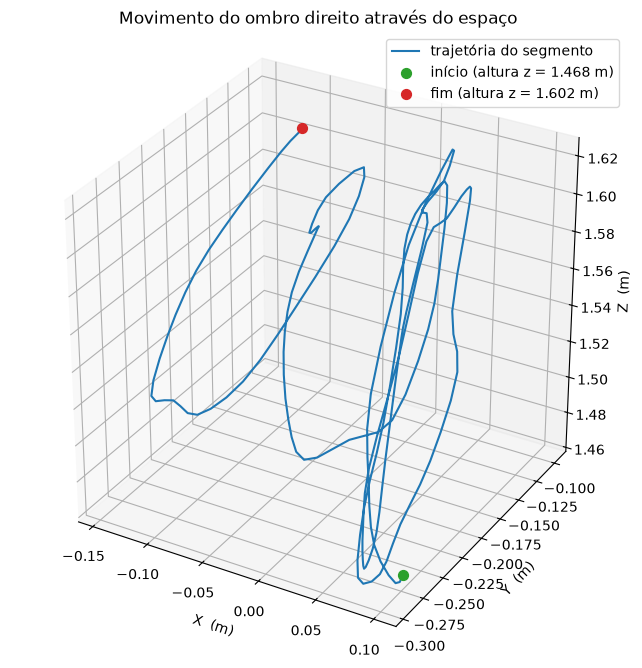

In [2]:
segmento_para_graficos = "RightShoulder"
junta_para_graficos = "jRightShoulder"
regra_abducao = RULES["shoulder_abduction"].mirrored()
regra_rotacao = RULES["shoulder_rotation"]
regra_flexao = RULES["shoulder_flexion"]
plot_segment_position(dados_captura, segmento_para_graficos, "Movimento do ombro direito através do espaço")

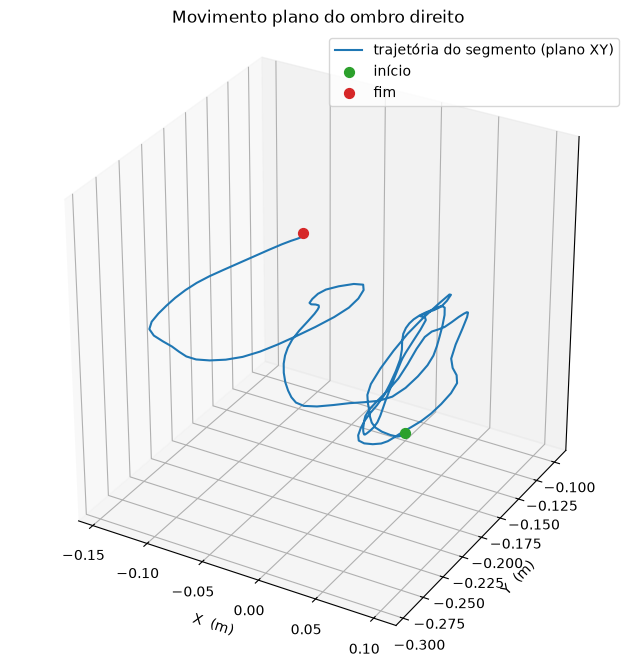

In [3]:
plot_flat_segment_position(dados_captura, segmento_para_graficos, "Movimento plano do ombro direito")

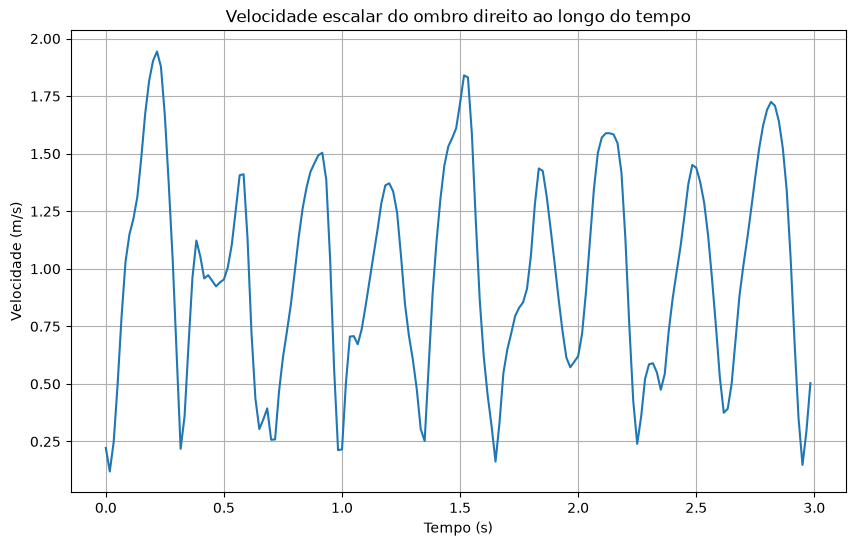

In [4]:
plot_segment_scalar_velocity(dados_captura, segmento_para_graficos, "Velocidade escalar do ombro direito ao longo do tempo")

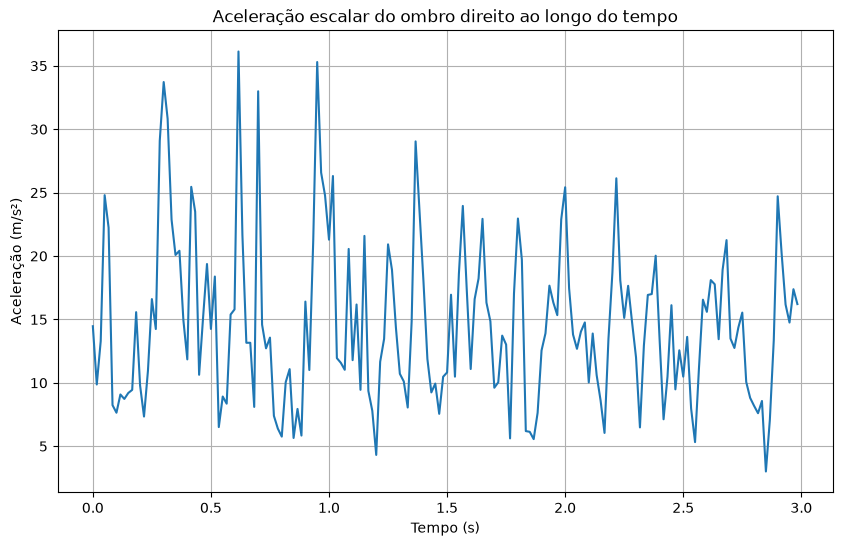

In [5]:
plot_segment_scalar_acceleration(dados_captura, segmento_para_graficos, "Aceleração escalar do ombro direito ao longo do tempo")

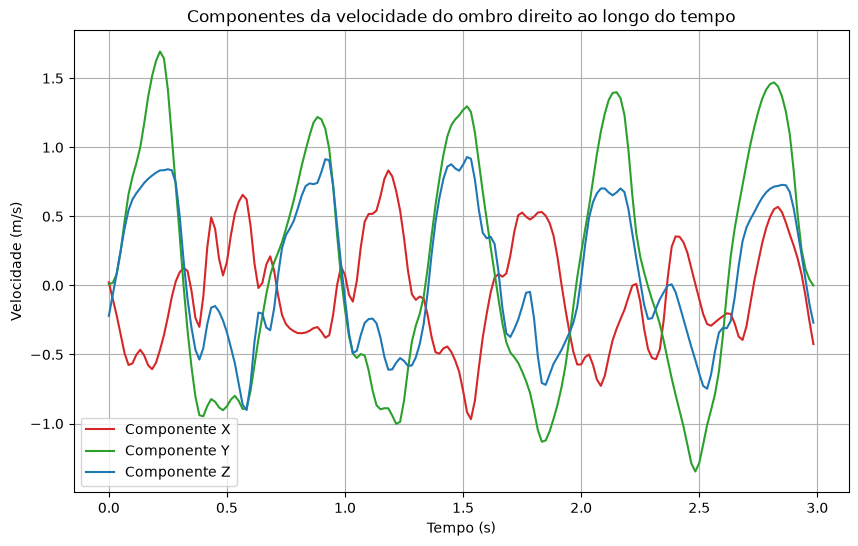

In [6]:
plot_segment_velocity_components(dados_captura, segmento_para_graficos, "Componentes da velocidade do ombro direito ao longo do tempo")

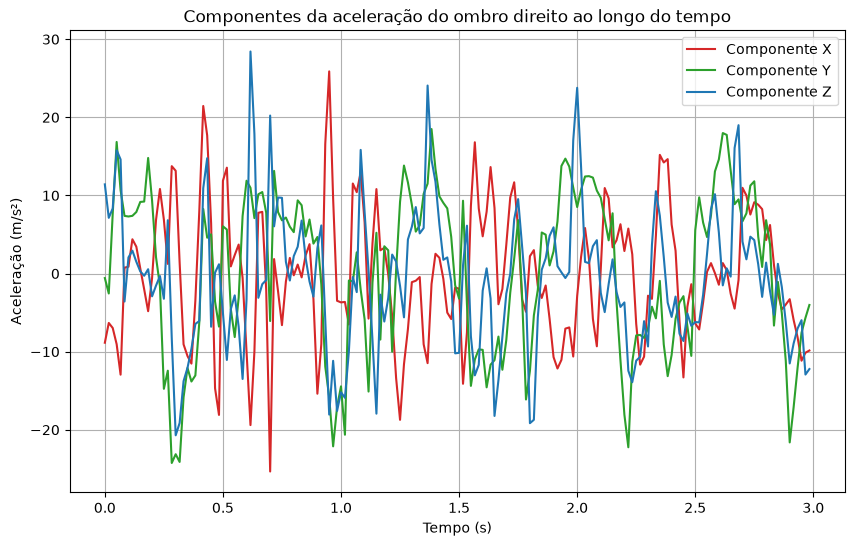

In [7]:
plot_segment_acceleration_components(dados_captura, segmento_para_graficos, "Componentes da aceleração do ombro direito ao longo do tempo")

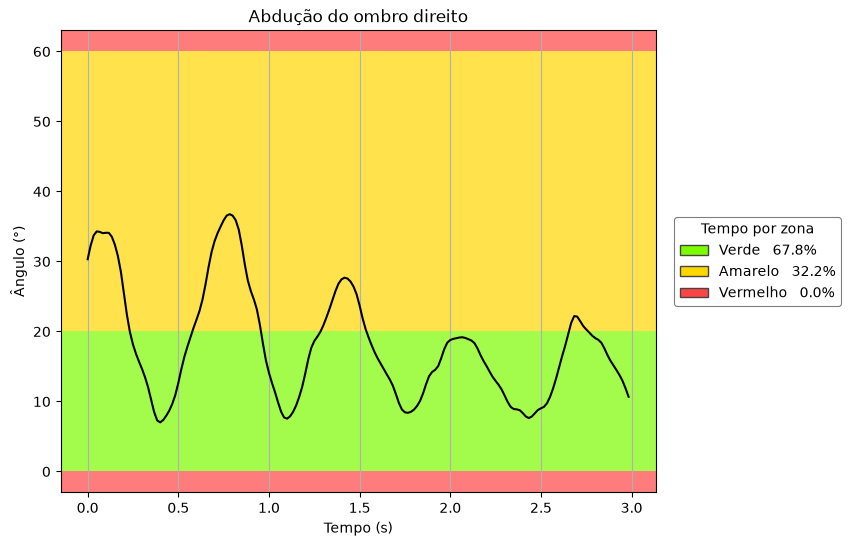

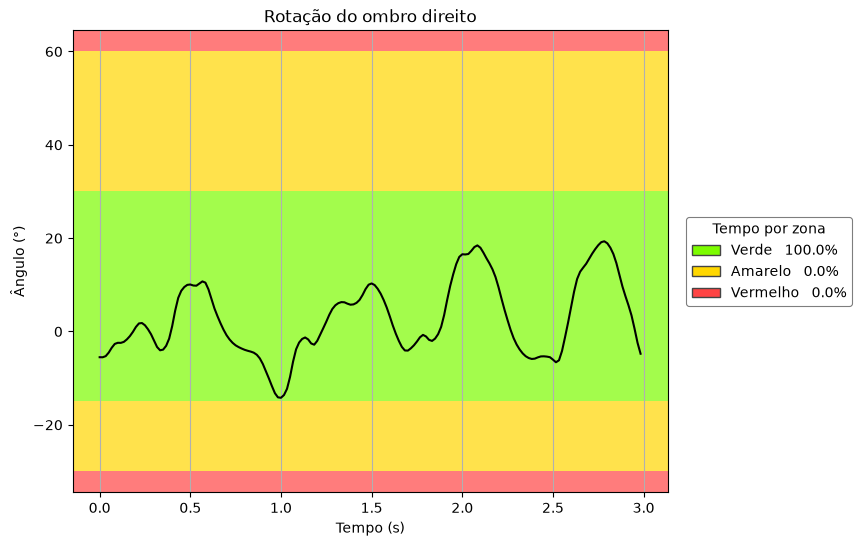

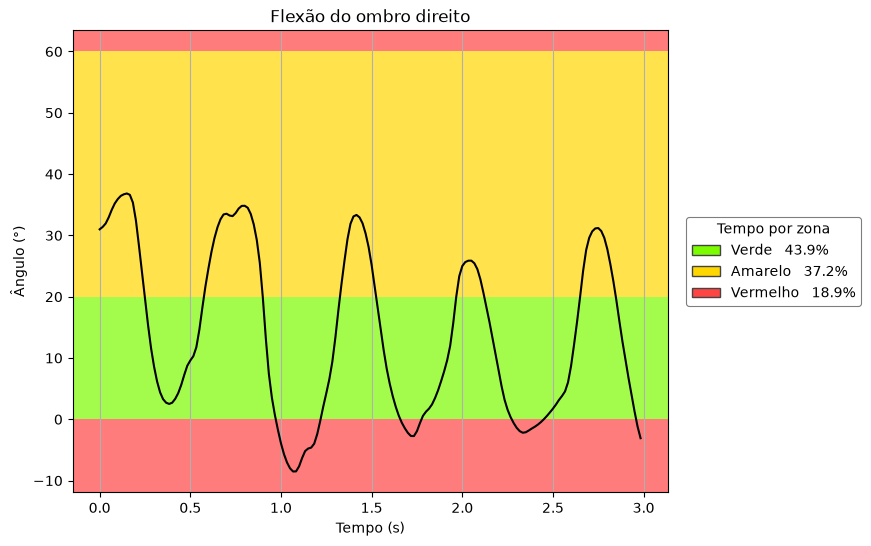

In [8]:
plot_abduction_byframe(
    dados_captura,
    junta_para_graficos,
    'Abdução do ombro direito',
    rule=regra_abducao,
)
plot_rotation_byframe(
    dados_captura,
    junta_para_graficos,
    'Rotação do ombro direito',
    rule=regra_rotacao,
)
plot_flexion_byframe(
    dados_captura,
    junta_para_graficos,
    'Flexão do ombro direito',
    rule=regra_flexao,
)

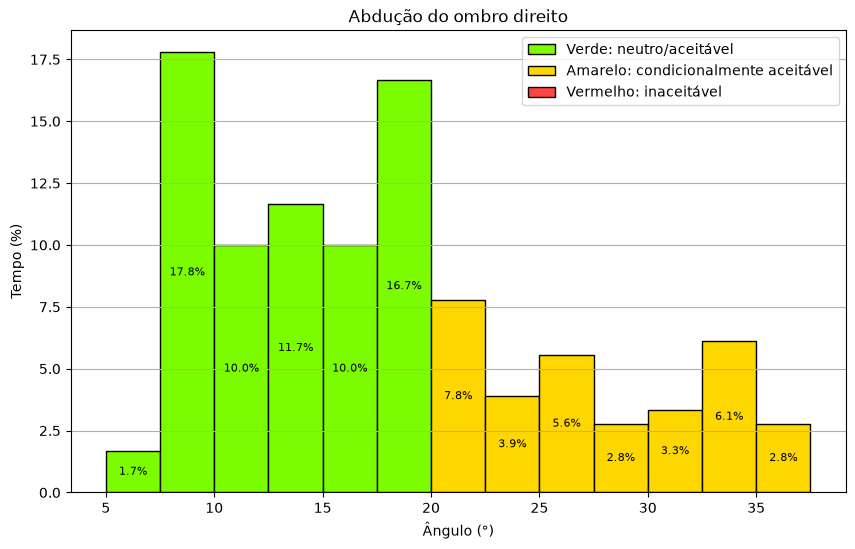

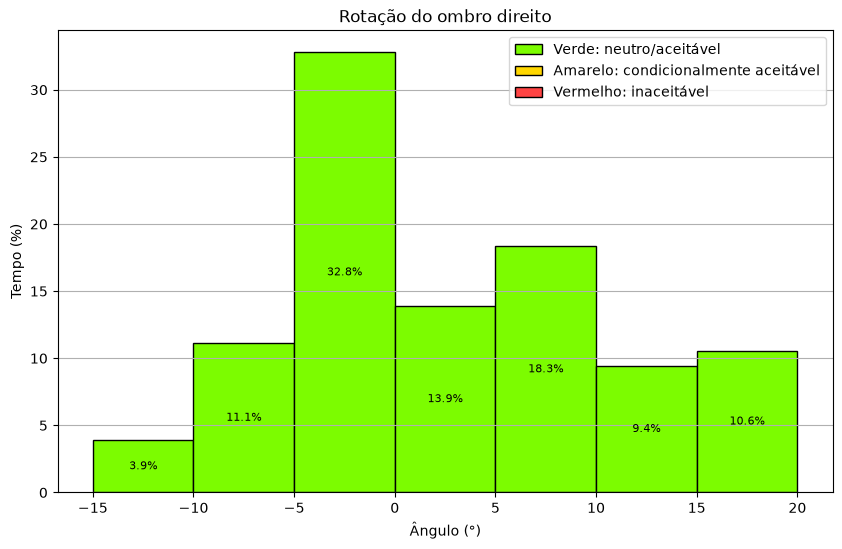

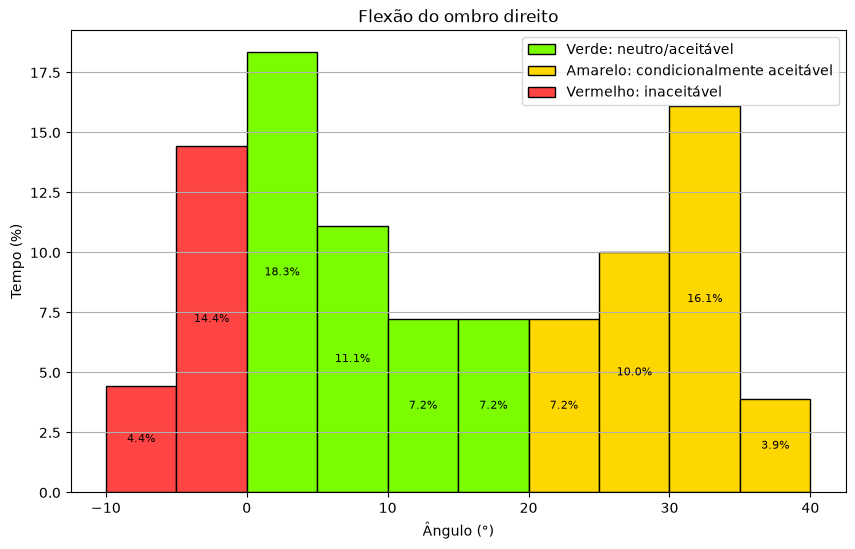

In [11]:
num_bins = 8
plot_abduction_histogram(
    dados_captura,
    junta_para_graficos,
    num_bins,
    'Abdução do ombro direito',
    rule=regra_abducao,
)
plot_rotation_histogram(
    dados_captura,
    junta_para_graficos,
    num_bins,
    'Rotação do ombro direito',
    rule=regra_rotacao,
)
plot_flexion_histogram(
    dados_captura,
    junta_para_graficos,
    num_bins,
    'Flexão do ombro direito',
    rule=regra_flexao,
)